In [29]:
import torch
import time
from d2l import torch as d2l
import torch.nn.functional as F
import matplotlib.pyplot as plt

### Exercise 1

In this section, we directly implemented the softmax function based on the mathematical definition of the softmax operation. As discussed in Section 4.1 this can cause numerical instabilities.
1. Test whether softmax still works correctly if an input has a value of 100 .
2. Test whether softmax still works correctly if the largest of all inputs is smaller than -100 ?
3. Implement a fix by looking at the value relative to the largest entry in the argument.

#### 4.1

In [8]:
def softmax(X):
    X_exp = torch.exp(X)
    partition = X_exp.sum(1, keepdims=True)
    return X_exp / partition  # The broadcasting mechanism is applied here

In [4]:
X = torch.tensor([[100.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
X_prob = softmax(X)
X_prob, X_prob.sum(1)

(tensor([[   nan, 0.0000, 0.0000],
         [0.0900, 0.2447, 0.6652]]),
 tensor([nan, 1.]))

This is numerical overflow.

#### 4.2

In [6]:
X = torch.tensor([[-1000.0, -1001.0, -1002.0], [4.0, 5.0, 6.0]])
X_prob = softmax(X)
X_prob, X_prob.sum(1)

(tensor([[   nan,    nan,    nan],
         [0.0900, 0.2447, 0.6652]]),
 tensor([nan, 1.]))

Extreme negative values cause underflow, just like large positives cause overflow.

#### 4.3

Let:
$$
m=\max _i x_i
$$
Then:
$$
x_i-m \leq 0
$$
So:
$$
\max _i\left(x_i-m\right)=0
$$
Now the largest exponent becomes:
$$
e^0=1
$$
All others are:
$$
e^{\text {negative }} \leq 1
$$
So:
- No overflow
- No catastrophic underflow
- Numerically stable

In [7]:
def softmax_stable(X):
    X_shifted = X - X.max(dim=1, keepdim=True).values
    X_exp = torch.exp(X_shifted)
    partition = X_exp.sum(dim=1, keepdim=True)
    return X_exp / partition

In [8]:
X = torch.tensor([[100.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
X_prob = softmax_stable(X)
X_prob, X_prob.sum(1)

(tensor([[1.0000e+00, 2.7465e-43, 7.4689e-43],
         [9.0031e-02, 2.4473e-01, 6.6524e-01]]),
 tensor([1., 1.]))

In [10]:
X = torch.tensor([[-1000.0, -1001.0, -1002.0], [4.0, 5.0, 6.0]])
X_prob = softmax_stable(X)
X_prob, X_prob.sum(1)

(tensor([[0.6652, 0.2447, 0.0900],
         [0.0900, 0.2447, 0.6652]]),
 tensor([1., 1.]))

### Exercise 2

Implement a cross_ent ropy function that follows the definition of the cross-entropy loss function $\sum_i y_i \log \hat{y}_i$.
1. Try it out in the code example of this section.
2. Why do you think it runs more slowly?
3. Should you use it? When would it make sense to?
4. What do you need to be careful of? Hint: consider the domain of the logarithm.

#### 2.1

Implementation in the note:

In [15]:
class SoftmaxRegressionScratch(d2l.Classifier):
    def __init__(self, num_inputs, num_outputs, lr, sigma=0.01):
        super().__init__()
        self.save_hyperparameters()
        self.W = torch.normal(0, sigma, size=(num_inputs, num_outputs),
                              requires_grad=True)
        self.b = torch.zeros(num_outputs, requires_grad=True)

    def parameters(self):
        return [self.W, self.b]

In [16]:
@d2l.add_to_class(SoftmaxRegressionScratch)
def forward(self, X):
    X = X.reshape((-1, self.W.shape[0]))
    return softmax(torch.matmul(X, self.W) + self.b)

In [17]:
def cross_entropy(y_hat, y):
    return -torch.log(y_hat[list(range(len(y_hat))), y]).mean()

In [18]:
@d2l.add_to_class(SoftmaxRegressionScratch)
def loss(self, y_hat, y):
    return cross_entropy(y_hat, y)

In [19]:
data = d2l.FashionMNIST(batch_size=256)
model = SoftmaxRegressionScratch(num_inputs=784, num_outputs=10, lr=0.1)
trainer = d2l.Trainer(max_epochs=10)

'30.23 sec'

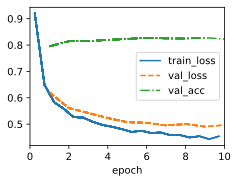

In [20]:
tic = time.time()
trainer.fit(model, data)
f'{time.time() - tic:.2f} sec'

Implementation directly

In [25]:
def cross_entropy_loop_index(y_hat, y):
    # y_hat: (B, C) probs; y: (B,) int labels
    eps = 1e-12
    total = 0.0
    B = y_hat.shape[0]
    for i in range(B):
        p = y_hat[i, y[i]]
        # domain guard: log needs p>0
        p = torch.clamp(p, min=eps)
        total = total - torch.log(p)
    return total / B

In [26]:
@d2l.add_to_class(SoftmaxRegressionScratch)
def loss(self, y_hat, y):
    return cross_entropy_loop_index(y_hat, y)

In [27]:
data = d2l.FashionMNIST(batch_size=256)
model = SoftmaxRegressionScratch(num_inputs=784, num_outputs=10, lr=0.1)
trainer = d2l.Trainer(max_epochs=10)

'36.56 sec'

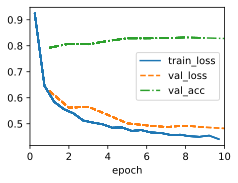

In [28]:
tic = time.time()
trainer.fit(model, data)
f'{time.time() - tic:.2f} sec'

#### 2.2

For loop makes things slower

#### 2.4

$\log$ requires $\hat{y}>0$

### Exercise 3

Is it always a good idea to return the most likely label? For example, would you do this for medical diagnosis? How would you try to address this?

Not always. "Return the most likely label" (argmax / MAP) is optimal only if your goal is 0-1 accuracy and all mistakes cost the same. In many real problems-medical diagnosis is the classic one-mistakes have very different consequences.

Why argmax can be bad (medical diagnosis intuition)
* A model might say:
    * Disease: 0.49
    * No disease: 0.51

Argmax returns "No disease." But a false negative could be catastrophic, while a false positive might just trigger a follow-up test.
- Rare conditions: even a small predicted probability could still warrant action if the cost of missing it is huge.

### Exercise 4

Assume that we want to use softmax regression to predict the next word based on some features. What are some problems that might arise from a large vocabulary?

Suppose:
$$
\hat{y}=\operatorname{softmax}(W x+b)
$$
If vocabulary size $=V$, then:
- $W$ is $d \times V$
- Output dimension is $V$
- Softmax must normalize over all $V$ words

Softmax requires computing:
$$
\exp \left(z_i\right) \text { for all } i=1, \ldots, V
$$
Then summing over all $V$.
So each forward pass costs $\mathbf{O}(\mathbf{V})$.
For language modeling:
- Vocab can be $50 \mathrm{k}-500 \mathrm{k}$
- This must be done for every training example

Training becomes very slow.

Most words are rare.

Zipf's law: a few words appear very often, most appear rarely.

Consequences:
- Rare words get very few updates.
- Poorly estimated probabilities.
- Overfitting on frequent words.
- Hard to generalize to unseen words.

Common words like:
- "the"
- "is"
- "and"
dominate training.

The model may learn to predict common words too often.

### Exercise 5

Experiment with the hyperparameters of the code in this section. In particular:
1. Plot how the validation loss changes as you change the learning rate.
2. Do the validation and training loss change as you change the minibatch size? How large or small do you need to go before you see an effect?

#### 5.1

In [30]:
class SoftmaxRegressionScratch(d2l.Classifier):
    def __init__(self, num_inputs, num_outputs, lr, sigma=0.01):
        super().__init__()
        self.save_hyperparameters()
        self.W = torch.normal(0, sigma, size=(num_inputs, num_outputs),
                              requires_grad=True)
        self.b = torch.zeros(num_outputs, requires_grad=True)

    def parameters(self):
        return [self.W, self.b]

In [31]:
class SoftmaxRegressionScratchNoPlot(SoftmaxRegressionScratch):
    def plot(self, key, value, train):
        pass

In [32]:
@d2l.add_to_class(SoftmaxRegressionScratchNoPlot)
def forward(self, X):
    X = X.reshape((-1, self.W.shape[0]))
    return softmax(torch.matmul(X, self.W) + self.b)

In [33]:
def cross_entropy(y_hat, y):
    return -torch.log(y_hat[list(range(len(y_hat))), y]).mean()

In [34]:
@d2l.add_to_class(SoftmaxRegressionScratchNoPlot)
def loss(self, y_hat, y):
    return cross_entropy(y_hat, y)

In [35]:
def evaluate_val_loss(model, data):
    """Compute average validation loss over the validation dataloader."""
    model.eval()
    total_loss = 0.0
    total_n = 0
    with torch.no_grad():
        for X, y in data.val_dataloader():
            y_hat = model(X)
            l = model.loss(y_hat, y)   # this is mean over batch
            bs = y.numel()
            total_loss += l.item() * bs
            total_n += bs
    model.train()
    return total_loss / total_n

In [36]:
def run_one_lr(lr, max_epochs=10, repeats=3, batch_size=256):
    val_losses = []

    for _ in range(repeats):
        data = d2l.FashionMNIST(batch_size=batch_size)

        model = SoftmaxRegressionScratchNoPlot(
            num_inputs=784, num_outputs=10, lr=lr
        )
        trainer = d2l.Trainer(max_epochs=max_epochs)
        trainer.fit(model, data)

        val_l = evaluate_val_loss(model, data)
        val_losses.append(val_l)

    return sum(val_losses) / len(val_losses)

lr=0.0001  val_loss=1.8946
lr=0.0003  val_loss=1.4714
lr=0.001  val_loss=1.0277
lr=0.003  val_loss=0.7834
lr=0.01  val_loss=0.6220
lr=0.03  val_loss=0.5379
lr=0.1  val_loss=0.4916
lr=0.3  val_loss=0.6763
lr=1  val_loss=nan


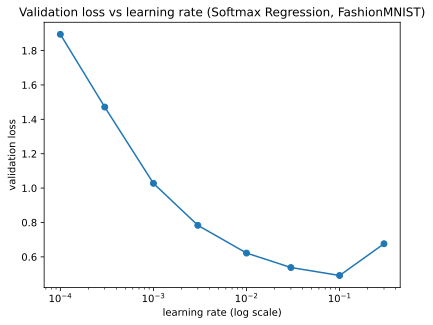

In [37]:
lrs = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1.0]

val_curve = []
for lr in lrs:
    v = run_one_lr(lr, max_epochs=10, repeats=3, batch_size=256)
    val_curve.append(v)
    print(f"lr={lr:g}  val_loss={v:.4f}")

plt.figure()
plt.plot(lrs, val_curve, marker='o')
plt.xscale('log')
plt.xlabel('learning rate (log scale)')
plt.ylabel('validation loss')
plt.title('Validation loss vs learning rate (Softmax Regression, FashionMNIST)')
plt.show()

#### 5.2

In [38]:
class SoftmaxRegressionScratch(d2l.Classifier):
    def __init__(self, num_inputs, num_outputs, lr, sigma=0.01):
        super().__init__()
        self.save_hyperparameters()
        self.W = torch.normal(0, sigma, size=(num_inputs, num_outputs),
                              requires_grad=True)
        self.b = torch.zeros(num_outputs, requires_grad=True)

    def parameters(self):
        return [self.W, self.b]

In [39]:
class SoftmaxRegressionScratchNoPlot(SoftmaxRegressionScratch):
    def plot(self, key, value, train):
        pass

In [40]:
@d2l.add_to_class(SoftmaxRegressionScratchNoPlot)
def forward(self, X):
    X = X.reshape((-1, self.W.shape[0]))
    return softmax(torch.matmul(X, self.W) + self.b)

In [41]:
def cross_entropy(y_hat, y):
    return -torch.log(y_hat[list(range(len(y_hat))), y]).mean()

In [42]:
@d2l.add_to_class(SoftmaxRegressionScratchNoPlot)
def loss(self, y_hat, y):
    return cross_entropy(y_hat, y)

In [46]:
def evaluate_loss(model, dataloader):
    model.eval()
    total_loss, total_n = 0.0, 0
    with torch.no_grad():
        for X, y in dataloader:
            y_hat = model(X)
            l = model.loss(y_hat, y)      # mean over batch
            bs = y.numel()
            total_loss += l.item() * bs
            total_n += bs
    model.train()
    return total_loss / total_n

In [47]:
def run_one_batch_size(batch_size, lr=0.1, max_epochs=10, repeats=3):
    train_losses = []
    val_losses = []

    for _ in range(repeats):
        data = d2l.FashionMNIST(batch_size=batch_size)
        model = SoftmaxRegressionScratchNoPlot(num_inputs=784, num_outputs=10, lr=lr)
        trainer = d2l.Trainer(max_epochs=max_epochs)
        trainer.fit(model, data)

        train_l = evaluate_loss(model, data.train_dataloader())
        val_l = evaluate_loss(model, data.val_dataloader())

        train_losses.append(train_l)
        val_losses.append(val_l)

    return (sum(train_losses)/len(train_losses), sum(val_losses)/len(val_losses))

batch_size=1    train_loss=nan val_loss=nan
batch_size=4    train_loss=0.6810 val_loss=0.8578
batch_size=8    train_loss=0.4848 val_loss=0.5914
batch_size=16   train_loss=0.4354 val_loss=0.5131
batch_size=32   train_loss=0.4153 val_loss=0.4755
batch_size=64   train_loss=0.4045 val_loss=0.4533
batch_size=128  train_loss=0.4224 val_loss=0.4638
batch_size=256  train_loss=0.4582 val_loss=0.4934
batch_size=512  train_loss=0.4827 val_loss=0.5125
batch_size=1024 train_loss=0.5206 val_loss=0.5477


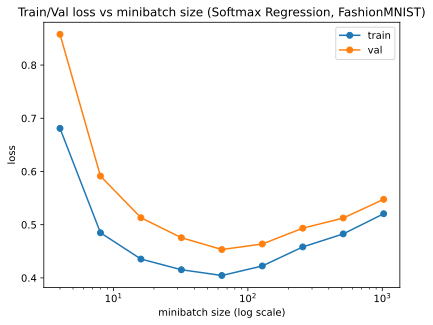

In [48]:
batch_sizes = [1, 4, 8, 16, 32, 64, 128, 256, 512, 1024]

train_curve = []
val_curve = []

for bs in batch_sizes:
    tr, va = run_one_batch_size(bs, lr=0.1, max_epochs=10, repeats=3)
    train_curve.append(tr)
    val_curve.append(va)
    print(f"batch_size={bs:<4d} train_loss={tr:.4f} val_loss={va:.4f}")

plt.figure()
plt.plot(batch_sizes, train_curve, marker='o', label='train')
plt.plot(batch_sizes, val_curve, marker='o', label='val')
plt.xscale('log')
plt.xlabel('minibatch size (log scale)')
plt.ylabel('loss')
plt.title('Train/Val loss vs minibatch size (Softmax Regression, FashionMNIST)')
plt.legend()
plt.show()